In [1]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from sklearn import metrics
import sys
from numpy import savetxt
import cmocean
import cmocean.cm as cmo

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.cbook import get_sample_data
import cv2
from skimage import io, transform
import plotly.express as px
import matplotlib.patches as mpatches 
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d

import umap.umap_ as umap
import seaborn as sns
import random


from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
import csv
import collections


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()

import json

with open('patient_rename.txt') as f:
    data = f.read()
js = json.loads(data)
print(js)

pt_ch_mapping ={
            # "EC130_513": [3],
            "EC186_200": [299, 300, 301],
            "EC222_200": [267, 268, 269, 270],
            "EC133_200": [282, 291, 292, 293],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            "EC175_200": [301, 302],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            "EC157_200": [321, 332, 333, 334],
            "EC135_200": [303],
            "EC219_200": [399, 400, 402, 403],
            "EC162_200": [85, 86],
            "EC143_200": [339],
            "EC137_200": [257, 258, 259, 269],
            "EC187_200": [309, 310],
            "EC130_200": [1, 13],
            "EC183_200": [290],
            }


all_specs_label = []
all_specs = np.empty((0, 60))
# all_specs = np.empty((0, 31293))
file_list = []
# pathname = '/home/dazhang/'
pathname = '/scratch/dazhang/MATLAB/'
for patient, channal_list in pt_ch_mapping.items():
    # if patient[:-4] != patient_of_interested:
    #      print("Only interested in patient: ", patient_of_interested)
    #      continue
    path = pathname + patient+'/'
    ls_specs = np.empty((0, 60))
    # ls_specs = np.empty((0, 31293))


    for cur_channel in channal_list:
        cur_channel = str(cur_channel) 
        cur_channel_list = []   
        for filename in glob.glob(os.path.join(path, '*.mat')):
            
                # each_file = 'ls_ripple_'+str(patient)+'_Channel_' + str(cur_channel) + '_binsize_10_Block_'+str(blk)+'.mat'
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f: 
                if "Channel_"+str(cur_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient]*len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print(all_specs.shape, all_specs_label.shape)




{'EC186': 'Pt 1', 'EC222': 'Pt 2', 'EC133': 'Pt 3', 'EC191': 'Pt 4', 'EC196': 'Pt 5', 'EC175': 'Pt 6', 'EC220': 'Pt 7', 'EC221': 'Pt 8', 'EC157': 'Pt 9', 'EC135': 'Pt 10', 'EC219': 'Pt 11', 'EC162': 'Pt 12', 'EC143': 'Pt 13', 'EC137': 'Pt 14', 'EC187': 'Pt 15', 'EC130': 'Pt 16', 'EC183': 'Pt 17'}
(31847, 60) (31847,)


(31847, 60)
UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Mon Sep 14 23:27:33 2026 Construct fuzzy simplicial set
Mon Sep 14 23:27:33 2026 Finding Nearest Neighbors
Mon Sep 14 23:27:33 2026 Building RP forest with 14 trees


/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Mon Sep 14 23:27:36 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Mon Sep 14 23:27:49 2026 Finished Nearest Neighbor Search
Mon Sep 14 23:27:51 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Mon Sep 14 23:27:57 2026 Finished embedding
[26395   739  9873 22545  7966]
KMeans(n_clusters=5, n_init=10, random_state=920)


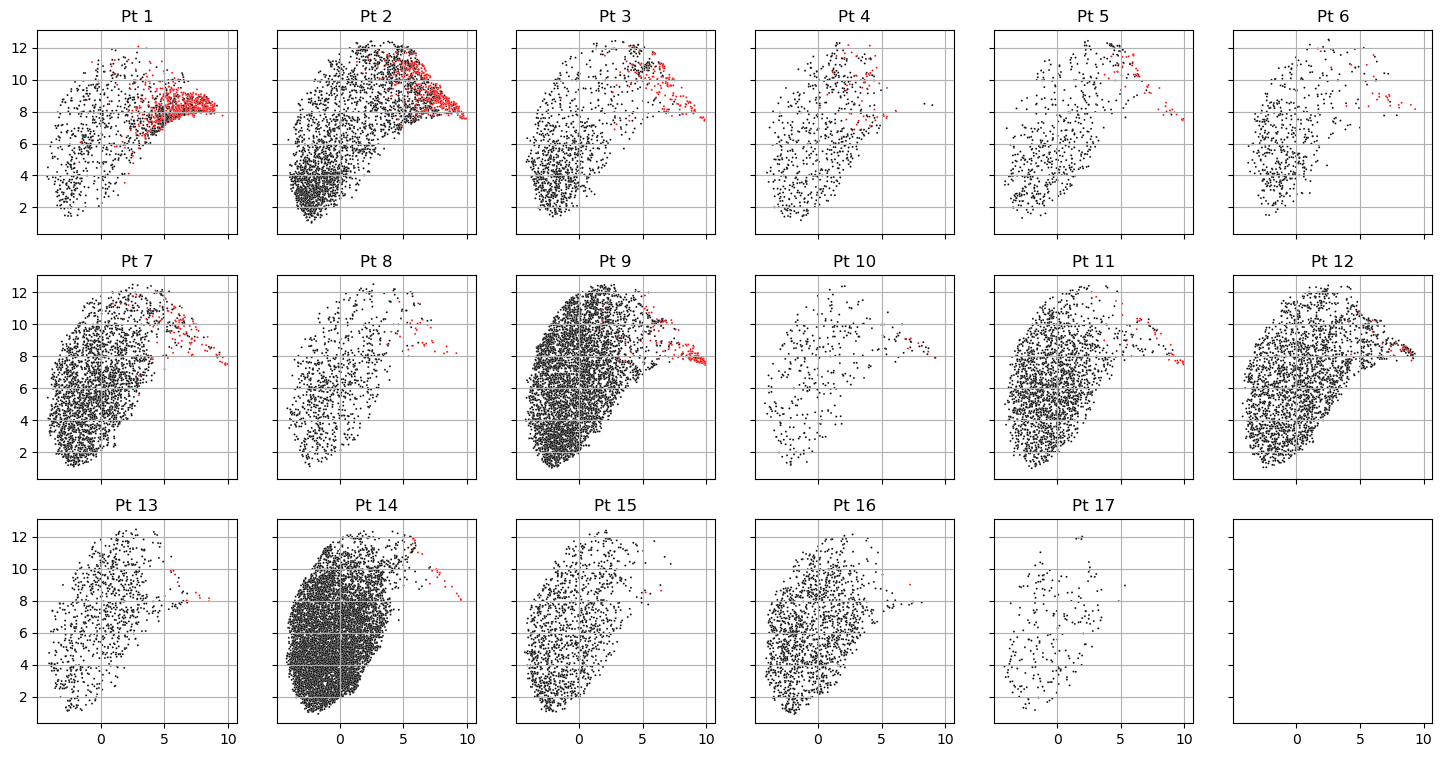

In [3]:
test_shape2 = []
all_spikes_label = np.empty((0, 1))
manual_label_spikes = list()
for each_file in file_list:
    
    patient_name = each_file.split("/")[-2]
    actural_file = each_file.split("/")[-1]
    actural_file_list = actural_file.split("_")
    # spike_file_name = patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])
    spike_file_name = pathname + patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])

    with open(spike_file_name, 'r') as f: 
        spikes = loadmat(spike_file_name)['ls_spikes']


    all_spikes_label = np.concatenate([all_spikes_label, spikes])
# print(all_spikes_label)

all_ripples = all_specs

print(all_ripples.shape)

all_vectors = np.asarray(all_ripples)




D_id_color = collections.defaultdict(str)


embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)
min_vals = np.min(embedding, axis=0)
max_vals = np.max(embedding, axis=0)
ratio = (max_vals[1] - min_vals[1])/(max_vals[0] - min_vals[0])



#Import required module
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
#Initialize the class object
#930 is good
kmeans = KMeans(n_clusters = 5,random_state = 920, n_init=10)
kmeans_label = kmeans.fit(embedding)
closest, all_points_w_labels = pairwise_distances_argmin_min(kmeans_label.cluster_centers_, embedding)

print(closest)
print(kmeans_label)




fig, axs = plt.subplots(3, 6, figsize=(18, 9), sharex=True, sharey=True)
count = 0
for patient_of_interested, channal_list in pt_ch_mapping.items():
    each_pt_embedding = np.empty((0, 2))
    each_pt_label = []

    for i, txt in enumerate(all_spikes_label):
        
        if all_specs_label[i] == patient_of_interested:
            # print(txt)
            spike = all_spikes_label[i]
            each_pt_embedding = np.concatenate([each_pt_embedding, embedding[i,:].reshape(-1, 2)], axis=0)
            if spike[0] == 0:
                # cc = [1, 1, 1]
                cc = [0, 0, 0]
            elif spike[0] == 1:
                cc = [1, 0, 0] 
                # cc = [0, 0, 0] 
        # else:https://vscode-remote+ssh-002dremote-002b10-002e37-002e40-002e74.vscode-resource.vscode-cdn.net/home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/plot_prob_dots_true_all_patients_200_new.png?version%3D1733099930447
        #     cc = [1, 1, 1] 
            each_pt_label.append(cc)

    ax = sns.scatterplot(x=each_pt_embedding[:,0], y=each_pt_embedding[:,1], c=each_pt_label, s=2, ax=axs[count//6][count%6])
    # ax.axis('equal')
    ax.set_aspect('auto')
    ax.grid(True)
    ax.title.set_text(js[patient_of_interested[:-4]])
    # ax.set_aspect('equal')
    count += 1
 
plt.show()
# plt.savefig("plot_prob_dots_true_all_patients_200_new.png", dpi=1200)
# plt.close()

In [ ]:
_